In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sys
import matplotlib.patches as mpatches
import matplotlib as mpl

# ---- Adobe-friendly fonts (must be set BEFORE plotting) ----
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42


df1 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/sensory/wiii8/nearest_neighbour.csv')
df1['condition'] = 'wiii8'


df2 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/sensory/anosmic/nearest_neighbour.csv')
df2['condition'] = 'anosmic'


df3 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/sensory/9047/nearest_neighbour.csv')
df3['condition'] = '9047'

df4 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/sensory/23129/nearest_neighbour.csv')
df4['condition'] = '23129'

df5 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/sensory/33300/nearest_neighbour.csv')
df5['condition'] = '33300'

df = pd.concat([df1, df2, df3, df4, df5], ignore_index=True)

condition_colors = {
    'wiii8': '#be0f0a',
    'anosmic': '#e7533a',
    '9047': "#a71394",
    '23129': "#3318e3",
    '33300': "#cfee1e",
}


In [2]:
"""
PER-CONDITION COMPARISON VS CONTROL (wiii8)

Same logic as GS/ghXpseudo/vision_nearest-neighbour-roseplot-3.py:
  - speed normalised to each animal's mean speed at 10-20 (baseline)
  - restrict to closest_node_distance 1-5, bin by 0.5
  - per angle bin: area between the test and control mean speed-vs-distance
    curves (trapz over distance)  ->  test - control
  - bootstrap over files (with replacement) for CIs + p-values
Plots are shown, not saved.
"""

mpl.rcParams['font.family'] = 'sans-serif'
mpl.rcParams['font.sans-serif'] = ['Arial']

CONTROL = 'wiii8'

# ---------------- preprocessing ----------------
d = df.copy()
d['condition'] = d['condition'].astype(str)
d['approach_angle'] = pd.to_numeric(d['approach_angle'], errors='coerce')

angle_edges = np.arange(0, 181, 30)  # 0,30,60,90,120,150,180
d['angle_bin'] = pd.cut(d['approach_angle'], angle_edges, include_lowest=True, right=False)
d = d.dropna(subset=['angle_bin'])
d['angle_bin'] = d['angle_bin'].astype(str)

# Baseline = each animal's own mean speed when FAR (10-20) from its nearest
# neighbour, i.e. its unaffected locomotor speed. Normalising by this is what
# makes slow mutants comparable to wiii8 -- speed_norm is a fractional change,
# not mm/s. Do NOT use the whole-track mean as the denominator: that contains
# the close-range frames you are measuring.
BASELINE_KEYS = ['condition', 'filename', 'track_id']   # per animal
# BASELINE_KEYS = ['condition', 'filename']             # per recording (old behaviour)

baseline = (
    d.loc[d['closest_node_distance'].between(10, 20, inclusive='both')]
     .groupby(BASELINE_KEYS)['speed']
     .mean()
     .rename('mean_speed_10_20')
     .reset_index()
)

# merge keys MUST match the groupby keys, otherwise this becomes a many-to-many join
d = d.merge(baseline, on=BASELINE_KEYS, how='left')

# report anything with no far-field frames before it gets silently dropped
_missing = d.loc[d['mean_speed_10_20'].isna(), BASELINE_KEYS].drop_duplicates()
if len(_missing):
    print(f'WARNING: dropping {len(_missing)} track(s) with no frames at 10-20:')
    print(_missing.groupby('condition').size())

d = d.dropna(subset=['mean_speed_10_20']).copy()
d['speed_norm'] = d['speed'] / d['mean_speed_10_20']

print('baseline level:', BASELINE_KEYS)
print(baseline.groupby('condition').agg(
    n_files=('filename', 'nunique'),
    n_tracks=('mean_speed_10_20', 'size'),
    min_baseline=('mean_speed_10_20', 'min'),
    median_baseline=('mean_speed_10_20', 'median'),
))

d = d[(d['closest_node_distance'] > 1) & (d['closest_node_distance'] <= 5)].copy()

bins = np.arange(1, 5.1, 0.5)
d['bin'] = pd.cut(d['closest_node_distance'], bins, include_lowest=True, right=True)
d['bin_center'] = d['bin'].apply(lambda x: x.mid)


# ---------------- area difference ----------------
def compute_area_difference(dataframe, test, control=CONTROL):
    """Per angle bin, integrated difference (test - control) of the mean normalised speed curve."""
    distance_means = (
        dataframe.groupby(['condition', 'filename', 'angle_bin', 'bin_center'])['speed_norm']
                 .mean().reset_index()
    )
    condition_mean_curves = (
        distance_means.groupby(['condition', 'angle_bin', 'bin_center'])['speed_norm']
                      .mean().reset_index().rename(columns={'speed_norm': 'mean_speed'})
    )
    wide = condition_mean_curves.pivot(
        index=['angle_bin', 'bin_center'], columns='condition', values='mean_speed'
    ).reset_index()
    wide = wide.dropna(subset=[test, control]).sort_values(['angle_bin', 'bin_center'])
    wide['speed_diff'] = wide[test] - wide[control]
    return wide.groupby('angle_bin').apply(
        lambda g: np.trapz(g['speed_diff'].to_numpy(), g['bin_center'].to_numpy())
    )


# ---------------- bootstrap ----------------
def bootstrap_comparison(test, control=CONTROL, resamples=1000, seed=0):
    """Resample files (with replacement) within each condition; returns effect + CI + p per angle bin."""
    rng = np.random.default_rng(seed)
    sub = d[d['condition'].isin([test, control])].copy()

    delta_area_real = compute_area_difference(sub, test, control)

    test_files = sub.loc[sub['condition'] == test, 'filename'].unique()
    ctrl_files = sub.loc[sub['condition'] == control, 'filename'].unique()
    by_file = {(c, f): g for (c, f), g in sub.groupby(['condition', 'filename'])}

    boot = []
    for b in range(resamples):
        t_sample = rng.choice(test_files, size=len(test_files), replace=True)
        c_sample = rng.choice(ctrl_files, size=len(ctrl_files), replace=True)

        parts = []
        for i, f in enumerate(t_sample):
            g = by_file[(test, f)].copy()
            g['filename'] = f'{f}__rep{i}'   # keep duplicates distinct so they count twice
            parts.append(g)
        for i, f in enumerate(c_sample):
            g = by_file[(control, f)].copy()
            g['filename'] = f'{f}__rep{i}'
            parts.append(g)

        df_boot = pd.concat(parts, ignore_index=True)
        boot.append(compute_area_difference(df_boot, test, control).rename(b))

    boot_df = pd.concat(boot, axis=1)

    results = delta_area_real.reset_index()
    results.columns = ['angle_bin', 'relative_area']
    results = results.set_index('angle_bin')
    results['ci_low'] = boot_df.quantile(0.025, axis=1)
    results['ci_high'] = boot_df.quantile(0.975, axis=1)
    results['p_value'] = 2 * np.minimum((boot_df <= 0).mean(axis=1), (boot_df >= 0).mean(axis=1))
    return results.reset_index()


# ---------------- roseplot ----------------
def angle_center(label):
    left = float(label.split(',')[0].strip('[('))
    right = float(label.split(',')[1].strip(' )]'))
    return (left + right) / 2


def sig_stars(p):
    if p < 0.001:
        return '***'
    if p < 0.01:
        return '**'
    if p < 0.05:
        return '*'
    return ''


def plot_roseplot(results, test, control=CONTROL, color=None, title=None):
    res = results.copy()
    res['angle_center_deg'] = res['angle_bin'].apply(angle_center)
    res = res.sort_values('angle_center_deg')

    theta = np.deg2rad(res['angle_center_deg'].to_numpy())
    width = np.deg2rad(30)

    delta = res['relative_area'].to_numpy()
    ci_low = res['ci_low'].to_numpy()
    ci_high = res['ci_high'].to_numpy()

    r = np.abs(delta)

    # signed CI -> magnitude CI
    mag_lo = np.where(delta >= 0, ci_low, -ci_high)
    mag_hi = np.where(delta >= 0, ci_high, -ci_low)
    crosses_zero = (ci_low <= 0) & (ci_high >= 0)
    mag_lo = np.where(crosses_zero, 0.0, mag_lo)

    ci_low_plot = np.clip(mag_lo, 0, None)
    ci_high_plot = np.clip(mag_hi, 0, None)

    fig = plt.figure(figsize=(7, 7))
    ax = plt.subplot(111, projection='polar')

    ax.bar(
        theta, r, width=width, align='center',
        color=color if color is not None else condition_colors.get(test, 'steelblue'),
        edgecolor='0.2', linewidth=1.5,
    )

    for th, lo, hi in zip(theta, ci_low_plot, ci_high_plot):
        ax.plot([th, th], [lo, hi], color='black', linewidth=2, solid_capstyle='round')

    ax.set_theta_zero_location('N')
    ax.set_theta_direction(-1)
    ax.set_thetamin(0)
    ax.set_thetamax(180)

    ax.set_yticklabels([])
    ax.yaxis.grid(False)
    ax.xaxis.grid(True, linewidth=1, alpha=0.8, color='0.3')
    ax.spines['polar'].set_linewidth(1)

    rmax = max(np.abs(ci_high_plot).max(), np.abs(r).max()) * 1.2
    if not np.isfinite(rmax) or rmax <= 0:
        rmax = 1.0
    ax.set_rlim(0, rmax)

    # significance stars from the bootstrap p-values
    for th, mag, hi, p in zip(theta, r, ci_high_plot, res['p_value'].to_numpy()):
        s = sig_stars(p)
        if s:
            ax.text(th, min(max(mag, hi) + rmax * 0.06, rmax * 0.95), s,
                    ha='center', va='center', fontsize=18, fontweight='bold')

    ax.set_frame_on(False)
    ax.set_xticks(np.deg2rad([0, 30, 60, 90, 120, 150, 180]))
    ax.set_xticklabels(['0\u00b0', '30\u00b0', '60\u00b0', '90\u00b0', '120\u00b0', '150\u00b0', '180\u00b0'])
    ax.set_title(title if title is not None else f'Speed Difference: {test} \u2212 {control}', pad=20)

    plt.tight_layout()
    plt.show()

condition
23129    1
dtype: int64
baseline level: ['condition', 'filename', 'track_id']
           n_files  n_tracks  min_baseline  median_baseline
condition                                                  
23129           10        50      0.367562         0.723218
33300           10        50      0.173693         0.572876
9047            10        50      0.361335         0.630654
anosmic         10        50      0.328374         0.660776
wiii8           10        50      0.497730         0.850804


anosmic vs wiii8
    angle_bin  relative_area    ci_low   ci_high  p_value
0     [0, 30)      -0.229311 -0.525384  0.088594    0.164
1  [120, 150)      -0.138375 -0.321478  0.039797    0.174
2  [150, 180)      -0.191687 -0.498626  0.134767    0.228
3    [30, 60)       0.028013 -0.231489  0.302135    0.834
4    [60, 90)      -0.072296 -0.336736  0.212054    0.654
5   [90, 120)       0.073345 -0.101317  0.264528    0.464


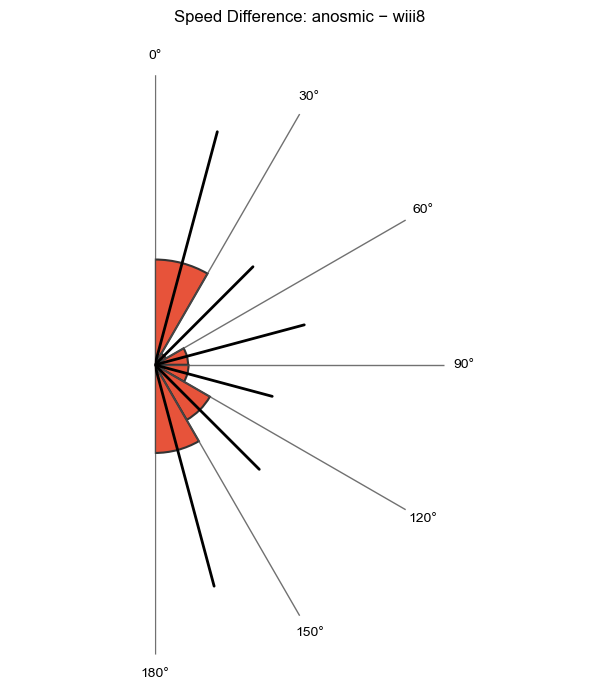

In [3]:
# ---- anosmic vs wiii8 ----
res_anosmic = bootstrap_comparison('anosmic')
print('anosmic vs', CONTROL)
print(res_anosmic)

plot_roseplot(res_anosmic, 'anosmic')

9047 vs wiii8
    angle_bin  relative_area    ci_low   ci_high  p_value
0     [0, 30)      -0.273933 -0.565345  0.018610    0.072
1  [120, 150)      -0.280551 -0.499816 -0.058104    0.014
2  [150, 180)      -0.240828 -0.612592  0.105446    0.184
3    [30, 60)      -0.077480 -0.311949  0.168299    0.544
4    [60, 90)      -0.155550 -0.456119  0.146213    0.326
5   [90, 120)      -0.008694 -0.239163  0.248242    0.960


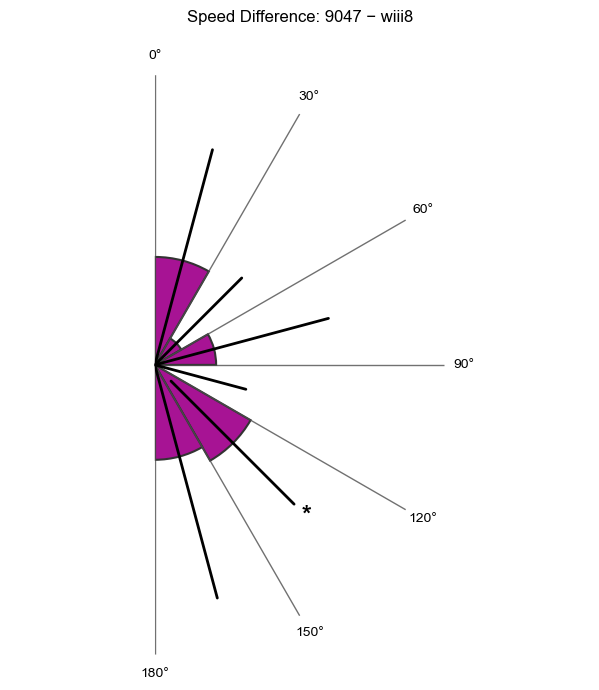

In [4]:
# ---- 9047 vs wiii8 ----
res_9047 = bootstrap_comparison('9047')
print('9047 vs', CONTROL)
print(res_9047)

plot_roseplot(res_9047, '9047')

23129 vs wiii8
    angle_bin  relative_area    ci_low   ci_high  p_value
0     [0, 30)      -0.309279 -0.627468  0.028124    0.066
1  [120, 150)      -0.062338 -0.245656  0.120900    0.496
2  [150, 180)      -0.096173 -0.349382  0.186318    0.478
3    [30, 60)      -0.066143 -0.322867  0.213794    0.666
4    [60, 90)      -0.083940 -0.379494  0.225614    0.632
5   [90, 120)       0.190783 -0.002288  0.402681    0.056


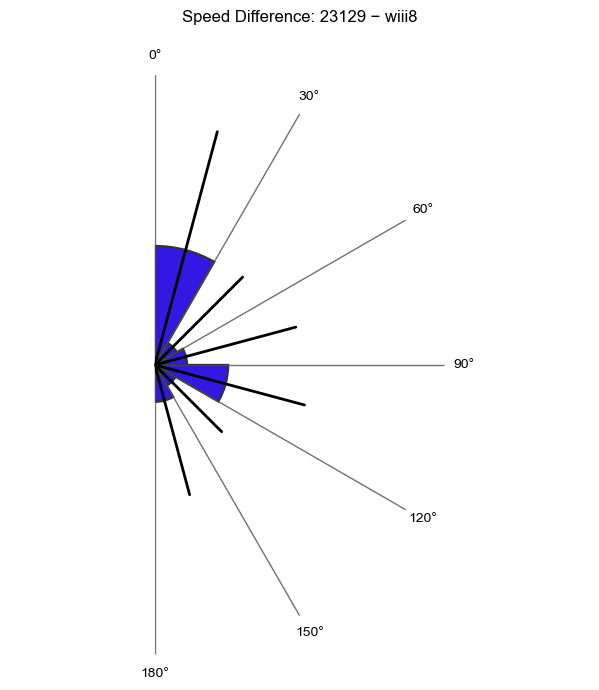

In [5]:
# ---- 23129 vs wiii8 ----
res_23129 = bootstrap_comparison('23129')
print('23129 vs', CONTROL)
print(res_23129)

plot_roseplot(res_23129, '23129')

33300 vs wiii8
    angle_bin  relative_area    ci_low   ci_high  p_value
0     [0, 30)      -0.105268 -0.441039  0.248711    0.586
1  [120, 150)       0.116328 -0.086867  0.301240    0.292
2  [150, 180)       0.051283 -0.232260  0.386294    0.754
3    [30, 60)       0.013494 -0.349273  0.364545    0.946
4    [60, 90)      -0.005818 -0.337772  0.334455    1.000
5   [90, 120)       0.163277 -0.172216  0.513595    0.386


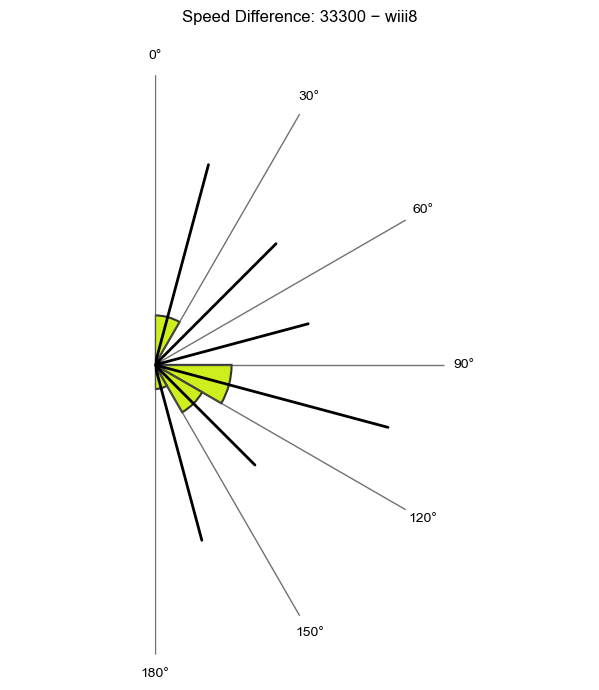

In [6]:
# ---- 33300 vs wiii8 ----
res_33300 = bootstrap_comparison('33300')
print('33300 vs', CONTROL)
print(res_33300)

plot_roseplot(res_33300, '33300')